In [1]:
from isofit.core.fileio import IO
from isofit.core.forward import ForwardModel
from isofit.inversion.inverse import Inversion
from isofit.inversion.inverse_simple import invert_algebraic
from isofit.configs import configs
from isofit.core.geometry import Geometry

import os
from glob import glob
import logging
import numpy as np
from spectral.io import envi
from spectral.io.envi import read_envi_header
import matplotlib.pyplot as plt
%matplotlib widget

from utilities import single_px_retrieval

# Enable the ISOFIT logger
logging.getLogger().setLevel(logging.INFO)

In [ ]:
# exploratory single-pixel retrievals for iterative improvements

# single pixels are mean rdn values over representative pixels of each of the three classes:
# white tarp, black tarp, aspen

# update from 7/29/25: switched to using the emit surface priors a la https://github.com/emit-sds/emit-sds-l2a/blob/develop/surface/surface_20240103_avirii.json
# generated 2 different surface models, mostly the same but with slightly different reference windows

In [2]:
# define file paths
home = '/store/carroll/col/2018/'
aspen = home+'test_roi/aspen/'
cal = home+'test_roi/calTarp/'

dir_insitu = home+'insitu/'

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.07828101..2.0].


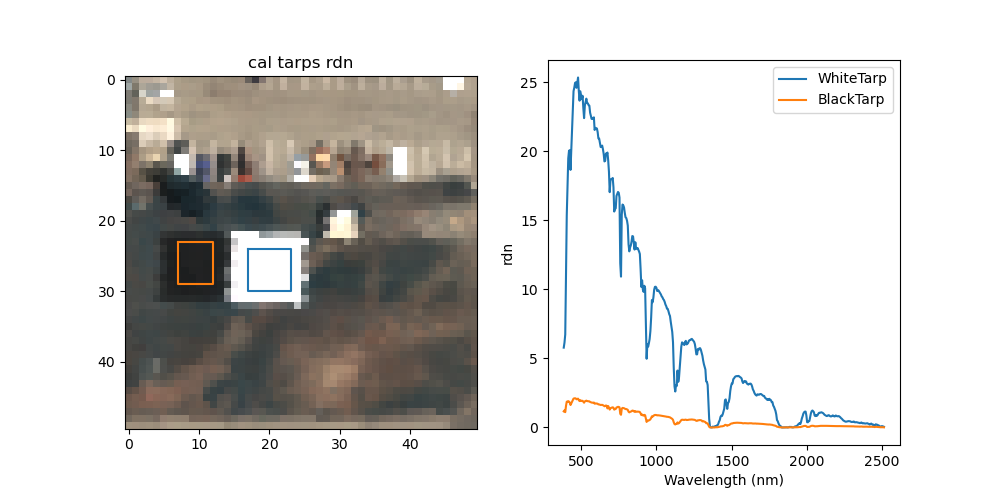

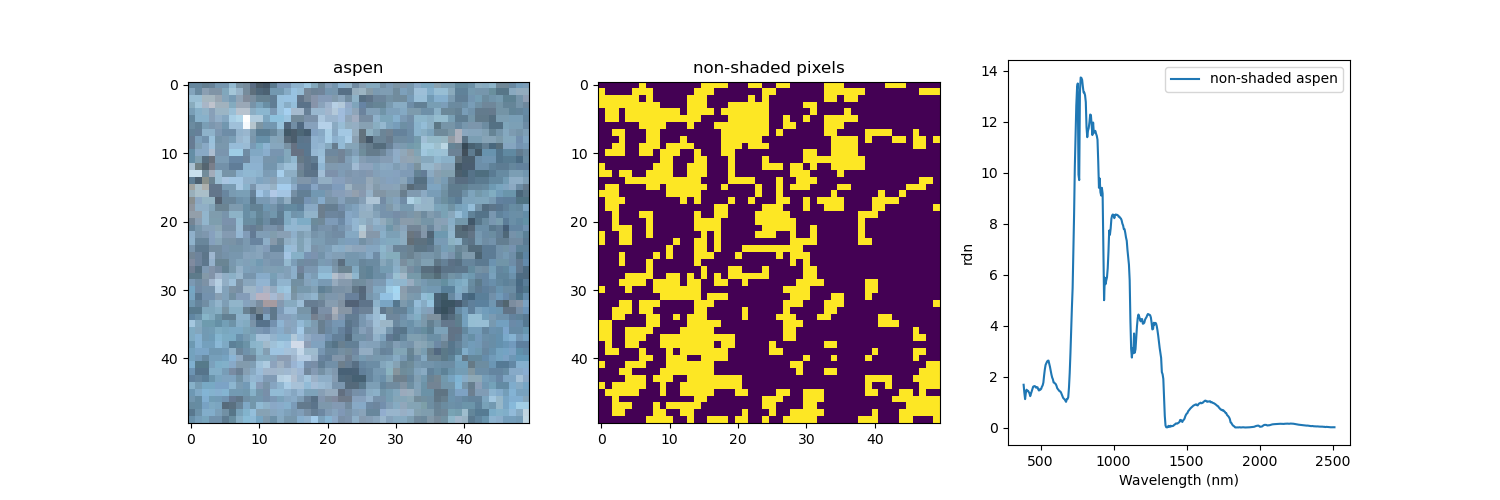

In [3]:
## define cal tarp roi
bboxes = {}
bboxes['WhiteTarp'] = [17,24,23,30]
bboxes['BlackTarp'] = [7,23,12,29]

# prepare representative single pixels
rdn = {}
obs = {}
loc = {}
for k in bboxes.keys():
    minx, miny, maxx, maxy = bboxes[k]
    fp = glob(os.path.join(cal, 'subset', '*_rdn.hdr'))[0]
    rdn[k] = np.nanmean(envi.open(fp).open_memmap(interleave='bip')[miny:maxy, minx:maxx, :], axis=(0,1))
    fp = glob(os.path.join(cal, 'subset', '*_obs.hdr'))[0]
    obs[k] = np.nanmean(envi.open(fp).open_memmap(interleave='bip')[miny:maxy, minx:maxx, :], axis=(0,1))
    fp = glob(os.path.join(cal, 'subset', '*_igm.hdr'))[0]
    loc[k] = np.nanmean(envi.open(fp).open_memmap(interleave='bip')[miny:maxy, minx:maxx, :], axis=(0,1))
for veg in ['aspen', 'conifer']:
    fp = glob(os.path.join(home, 'test_roi', veg, 'subset', '*_rdn.hdr'))[0]
    tmp = envi.open(fp).open_memmap(interleave='bip').copy()
    shaded = np.sum(tmp[...,[60,40,30]], axis=2) < 5
    tmp[shaded, :] = np.nan
    rdn[veg] = np.nanmean(tmp, axis=(0,1))
    fp = glob(os.path.join(home, 'test_roi', veg, 'subset', '*_obs.hdr'))[0]
    tmp  = envi.open(fp).open_memmap(interleave='bip').copy()
    tmp[shaded, :] = np.nan
    obs[veg] = np.nanmean(tmp, axis=(0,1))
    fp = glob(os.path.join(home, 'test_roi', veg, 'subset', '*_igm.hdr'))[0]
    tmp  = envi.open(fp).open_memmap(interleave='bip').copy()
    tmp[shaded, :] = np.nan
    loc[veg] = np.nanmean(tmp, axis=(0,1))

# visualize full rdn w regions averaged to single pixels

# cal tarps
fig, axs = plt.subplots(ncols=2, figsize=(10,5))
fp = glob(os.path.join(cal, 'subset', '*_rdn.hdr'))[0]
wl = [float(x) for x in read_envi_header(fp)['wavelength']]
rgb = envi.open(fp).open_memmap(interleave='bip')[:,:,np.array([60,40,30])].copy()
axs[0].imshow(rgb / np.max(rgb, axis=(0, 1))*2)
for k, (minx, miny, maxx, maxy) in bboxes.items():
    x = [minx, maxx, maxx, minx, minx]
    y = [miny, miny, maxy, maxy, miny]
    axs[0].plot(x, y, label=k)
axs[0].set_title('cal tarps rdn')
axs[1].plot(wl, rdn['WhiteTarp'], label='WhiteTarp')
axs[1].plot(wl, rdn['BlackTarp'], label='BlackTarp')
axs[1].legend()
axs[1].set_xlabel('Wavelength (nm)')
axs[1].set_ylabel('rdn')
plt.show()

# aspen
fig, axs = plt.subplots(ncols=3, figsize=(15, 5))
fp = glob(os.path.join(home, 'test_roi', 'aspen', 'subset', '*_rdn.hdr'))[0]
rgb = envi.open(fp).open_memmap(interleave='bip')[:,:,np.array([60,40,30])].copy()
axs[0].imshow(rgb / np.max(rgb, axis=(0, 1)))
axs[0].set_title('aspen')
lit = np.sum(rgb, axis=2)
valid = lit > 5
axs[1].imshow(valid)
axs[1].set_title('non-shaded pixels')
axs[2].plot(wl, rdn['aspen'], label='non-shaded aspen')
axs[2].legend()
axs[2].set_xlabel('Wavelength (nm)')
axs[2].set_ylabel('rdn')
plt.show()

In [11]:
config.forward_model.instrument.statevector.__dict__

{'_H2OSTR_type': isofit.configs.sections.statevector_config.StateVectorElementConfig,
 'H2OSTR': None,
 '_AOT550_type': isofit.configs.sections.statevector_config.StateVectorElementConfig,
 'AOT550': None,
 '_AERFRAC_1_type': isofit.configs.sections.statevector_config.StateVectorElementConfig,
 'AERFRAC_1': None,
 '_AERFRAC_2_type': isofit.configs.sections.statevector_config.StateVectorElementConfig,
 'AERFRAC_2': None,
 '_AERFRAC_3_type': isofit.configs.sections.statevector_config.StateVectorElementConfig,
 'AERFRAC_3': None,
 '_GROW_FWHM_type': isofit.configs.sections.statevector_config.StateVectorElementConfig,
 'GROW_FWHM': None,
 '_WL_SHIFT_type': isofit.configs.sections.statevector_config.StateVectorElementConfig,
 'WL_SHIFT': None,
 '_WL_SPACE_type': isofit.configs.sections.statevector_config.StateVectorElementConfig,
 'WL_SPACE': None,
 '_AIRT_DELTA_K_type': isofit.configs.sections.statevector_config.StateVectorElementConfig,
 'AIRT_DELTA_K': None}

In [15]:
config.forward_model.radiative_transfer.statevector.__dict__

{'_H2OSTR_type': isofit.configs.sections.statevector_config.StateVectorElementConfig,
 'H2OSTR': <isofit.configs.sections.statevector_config.StateVectorElementConfig at 0x7f522504ac00>,
 '_AOT550_type': isofit.configs.sections.statevector_config.StateVectorElementConfig,
 'AOT550': <isofit.configs.sections.statevector_config.StateVectorElementConfig at 0x7f522504b440>,
 '_AERFRAC_1_type': isofit.configs.sections.statevector_config.StateVectorElementConfig,
 'AERFRAC_1': None,
 '_AERFRAC_2_type': isofit.configs.sections.statevector_config.StateVectorElementConfig,
 'AERFRAC_2': None,
 '_AERFRAC_3_type': isofit.configs.sections.statevector_config.StateVectorElementConfig,
 'AERFRAC_3': None,
 '_GROW_FWHM_type': isofit.configs.sections.statevector_config.StateVectorElementConfig,
 'GROW_FWHM': None,
 '_WL_SHIFT_type': isofit.configs.sections.statevector_config.StateVectorElementConfig,
 'WL_SHIFT': None,
 '_WL_SPACE_type': isofit.configs.sections.statevector_config.StateVectorElementConfi

INFO:root:Loading config file: /store/carroll/col/2018/test_roi/calTarp/NIS01_20180611_172310_sRTMnet/config/NIS01_20180611_172310_isofit.json
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/radiative_transfer_engine.py:Loading from wavelength_file: /store/carroll/col/2018/test_roi/calTarp/NIS01_20180611_172310_sRTMnet/data/wavelengths.txt
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/radiative_transfer_engine.py:Prebuilt LUT provided
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/luts.py:Loading LUT into memory
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/radiative_transfer_engine.py:LUT grid loaded from file: OrderedDict({'AOT550': [0.0001, 0.050098333333333335, 0.10009666666666667, 0.15009499999999998, 0.20009333333333332, 0.25009166666666666, 0.30008999999999997, 

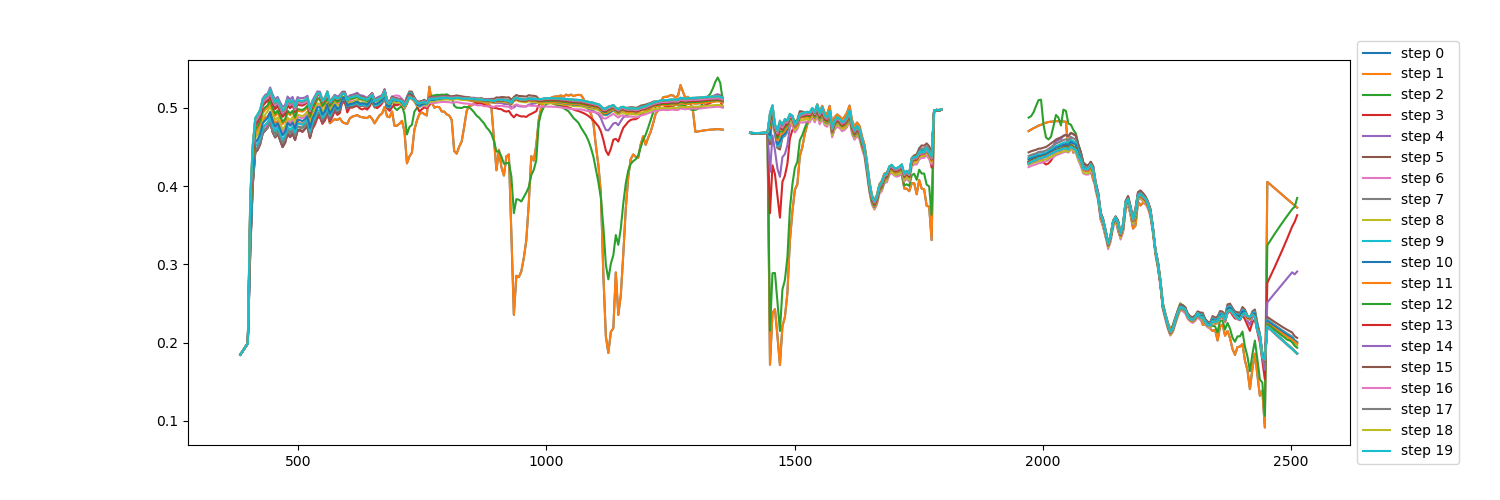

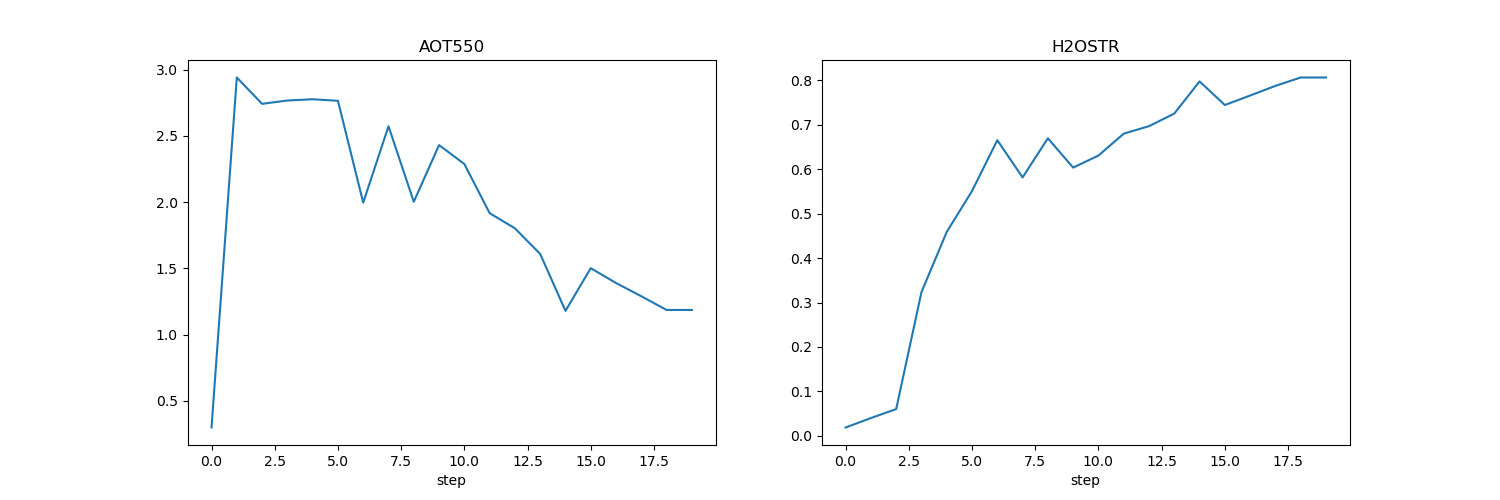

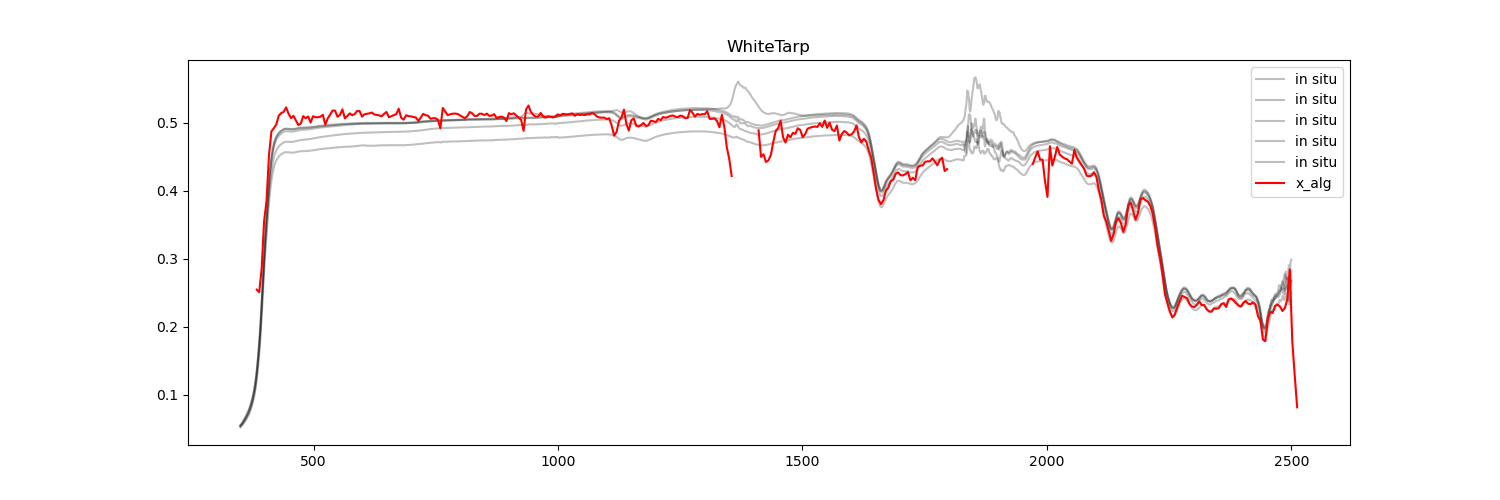

In [4]:
# white tarp

k = 'WhiteTarp'
fol = cal

# load, update config file
fp = glob(os.path.join(fol, '*', 'config', '*_isofit.json'))[0]
config = configs.create_new_config(fp)
config.forward_model.surface.surface_file = os.path.join(home, 'test_roi/surface_20240103_avirii_20250730.mat') # different from what was used in apply_oe!
config.input.measured_radiance_file = glob(os.path.join(fol, 'subset', '*_rdn'))[0]
config.input.obs_file = glob(os.path.join(fol, 'subset', '*_obs'))[0]
config.input.loc_file = glob(os.path.join(fol, 'subset', '*_igm'))[0]

# run retrieval
x_alg, Ls, coeffs, wl = single_px_retrieval(config, rdn[k], obs[k], loc[k])

# final rfl solution w/ in situ
fps = glob(os.path.join(dir_insitu, f'KBDU_*white', 'Data', f'KBDU_*white_Refl.dat'))
fig = plt.figure(figsize=(15,5))
for fp in fps:
    in_situ = np.genfromtxt(fp, skip_header=3)
    plt.plot(in_situ[:,0], in_situ[:,1], label=f'in situ',c='black', alpha=0.25)
plt.plot(wl, x_alg, label='x_alg', c='red')
plt.title(f'{k}')
plt.legend()
plt.show()

INFO:root:Loading config file: /store/carroll/col/2018/test_roi/calTarp/NIS01_20180611_172310_sRTMnet/config/NIS01_20180611_172310_isofit.json
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/radiative_transfer_engine.py:Loading from wavelength_file: /store/carroll/col/2018/test_roi/calTarp/NIS01_20180611_172310_sRTMnet/data/wavelengths.txt
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/radiative_transfer_engine.py:Prebuilt LUT provided
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/luts.py:Loading LUT into memory
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/radiative_transfer_engine.py:LUT grid loaded from file: OrderedDict({'AOT550': [0.0001, 0.050098333333333335, 0.10009666666666667, 0.15009499999999998, 0.20009333333333332, 0.25009166666666666, 0.30008999999999997, 

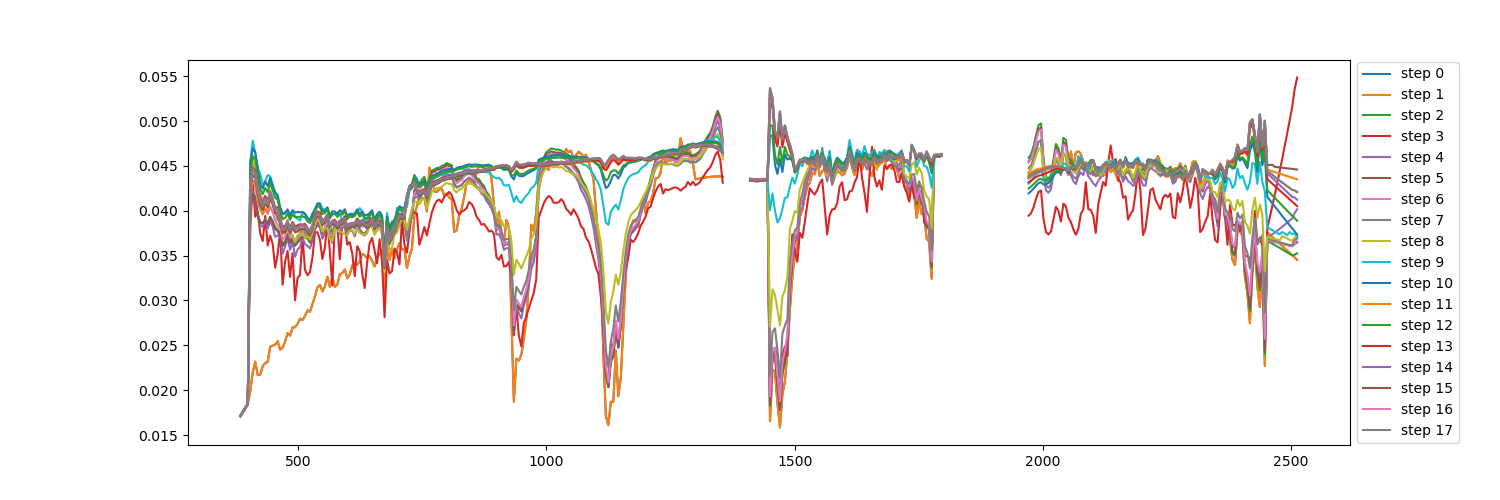

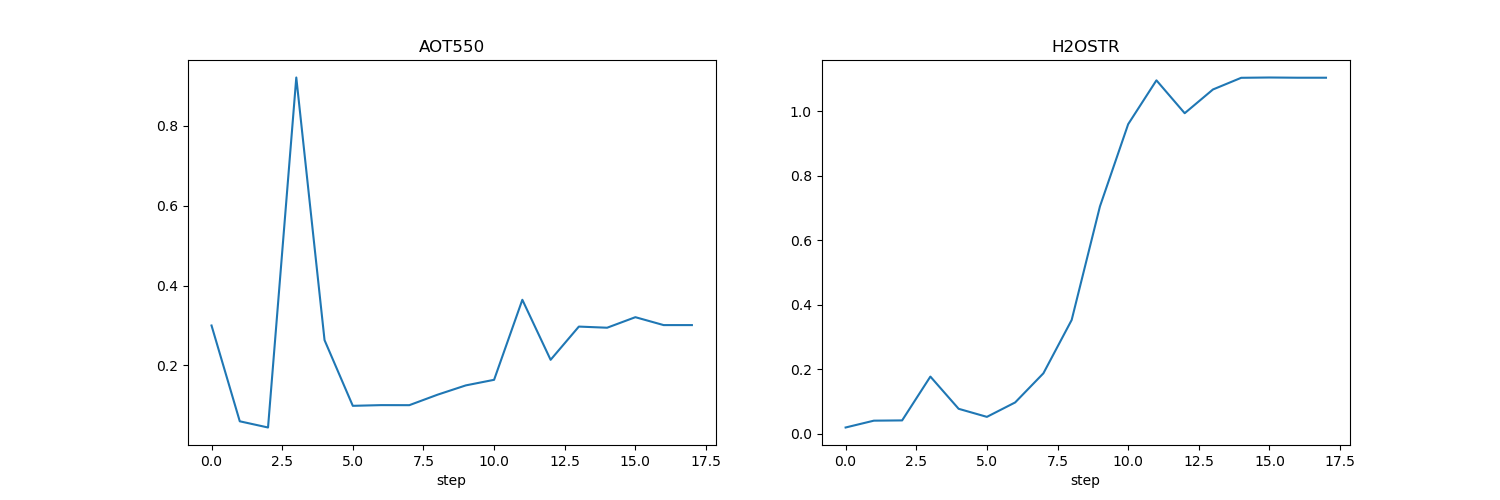

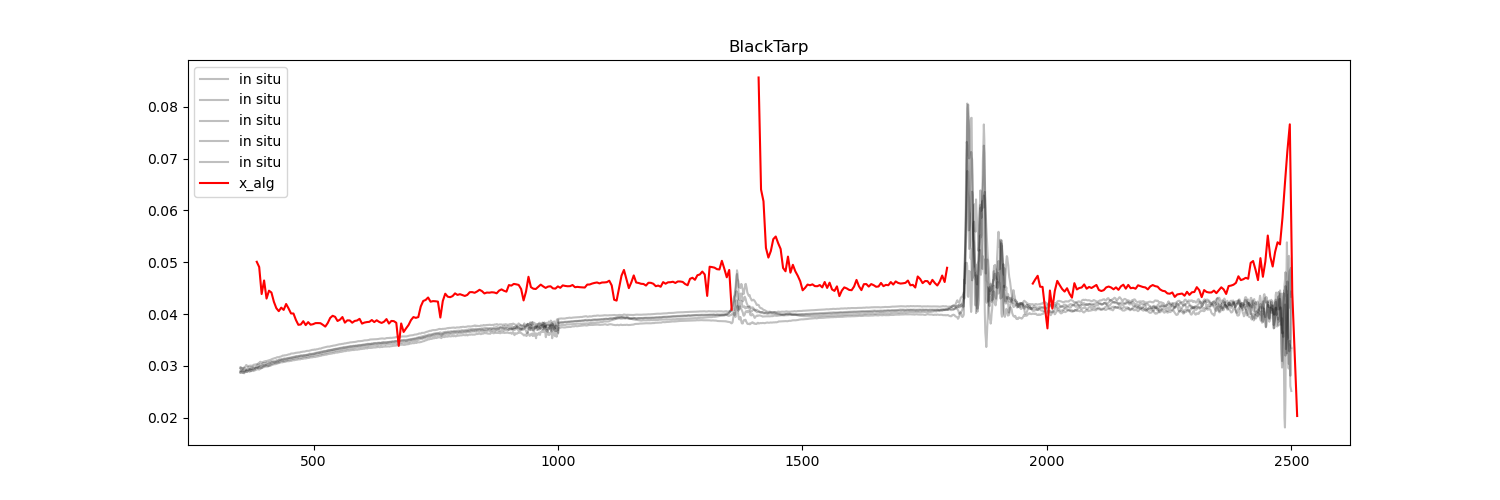

In [6]:
# black tarp

k = 'BlackTarp'
fol = cal

# load, update config file
fp = glob(os.path.join(fol, '*', 'config', '*_isofit.json'))[0]
config = configs.create_new_config(fp)
config.forward_model.surface.surface_file = os.path.join(home, 'test_roi/surface_20240103_avirii_20250730.mat') # different from what was used in apply_oe!
config.input.measured_radiance_file = glob(os.path.join(fol, 'subset', '*_rdn'))[0]
config.input.obs_file = glob(os.path.join(fol, 'subset', '*_obs'))[0]
config.input.loc_file = glob(os.path.join(fol, 'subset', '*_igm'))[0]

# run retrieval
x_alg, Ls, coeffs, wl = single_px_retrieval(config, rdn[k], obs[k], loc[k])

# final rfl solution w/ in situ
fps = glob(os.path.join(dir_insitu, f'KBDU_*black', 'Data', f'KBDU_*black_Refl.dat'))
fig = plt.figure(figsize=(15,5))
for fp in fps:
    in_situ = np.genfromtxt(fp, skip_header=3)
    plt.plot(in_situ[:,0], in_situ[:,1], label=f'in situ',c='black', alpha=0.25)
# plt.plot(wl, x_surface, label='x_surface') # , ls='--'
plt.plot(wl, x_alg, label='x_alg', c='red')
plt.title(f'{k}')
plt.legend()
plt.show()

INFO:root:Loading config file: /store/carroll/col/2018/test_roi/aspen/NIS01_20180619_172934_sRTMnet/config/NIS01_20180619_172934_isofit.json
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/radiative_transfer_engine.py:Loading from wavelength_file: /store/carroll/col/2018/test_roi/aspen/NIS01_20180619_172934_sRTMnet/data/wavelengths.txt
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/radiative_transfer_engine.py:Prebuilt LUT provided
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/luts.py:Loading LUT into memory
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/radiative_transfer_engine.py:LUT grid loaded from file: OrderedDict({'AOT550': [0.0001, 0.050098333333333335, 0.10009666666666667, 0.15009499999999998, 0.20009333333333332, 0.25009166666666666, 0.30008999999999997, 0.35

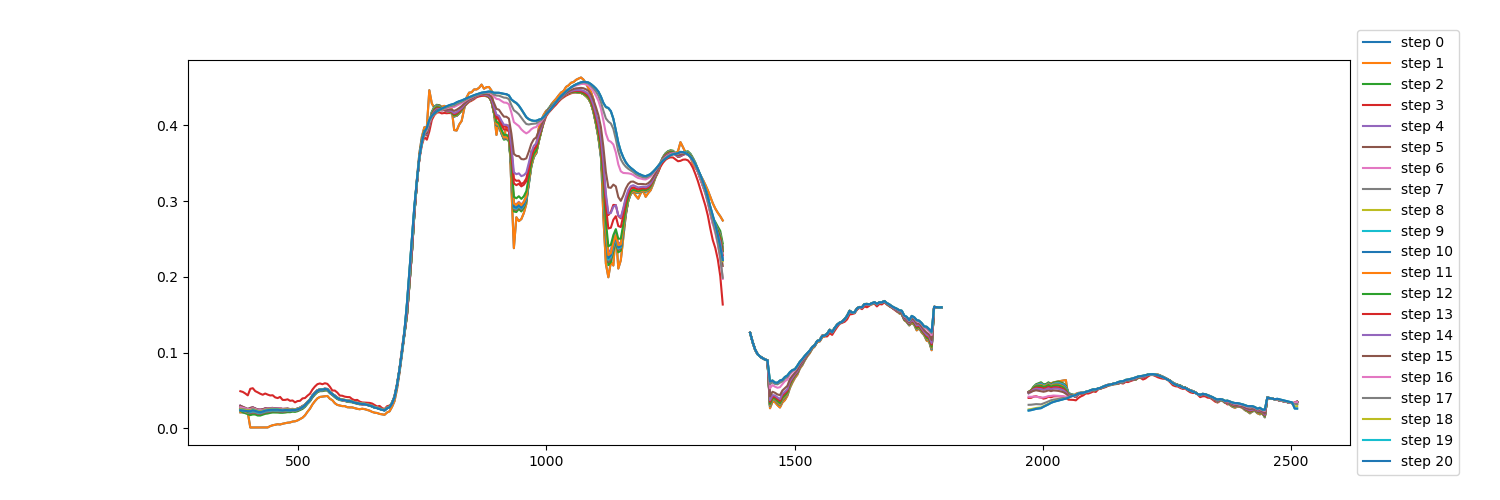

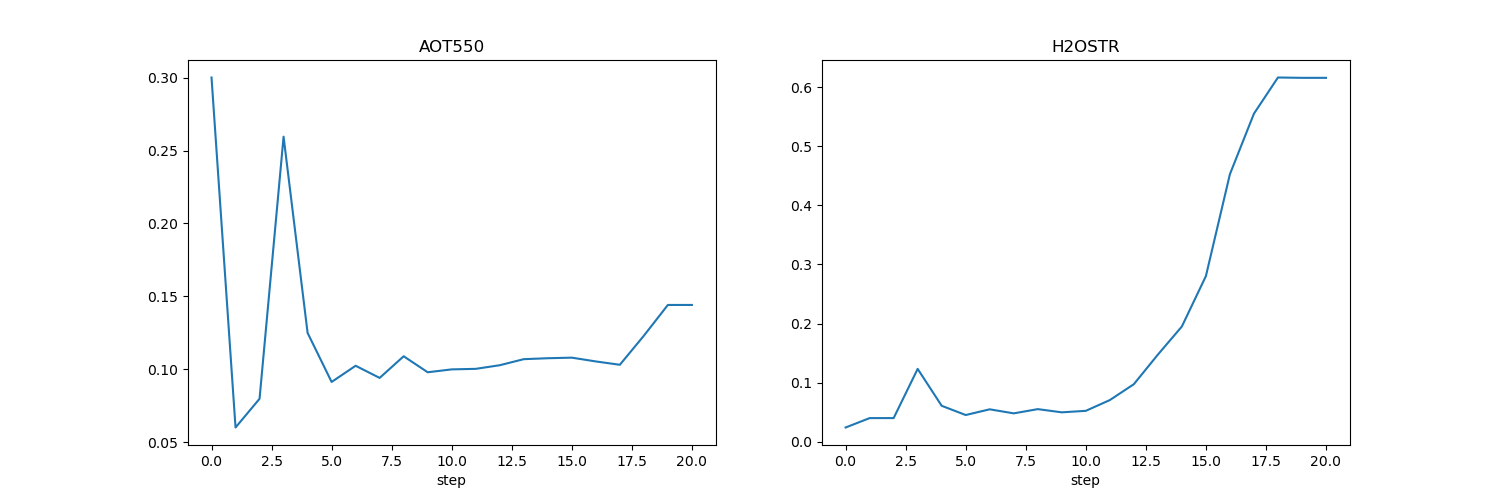

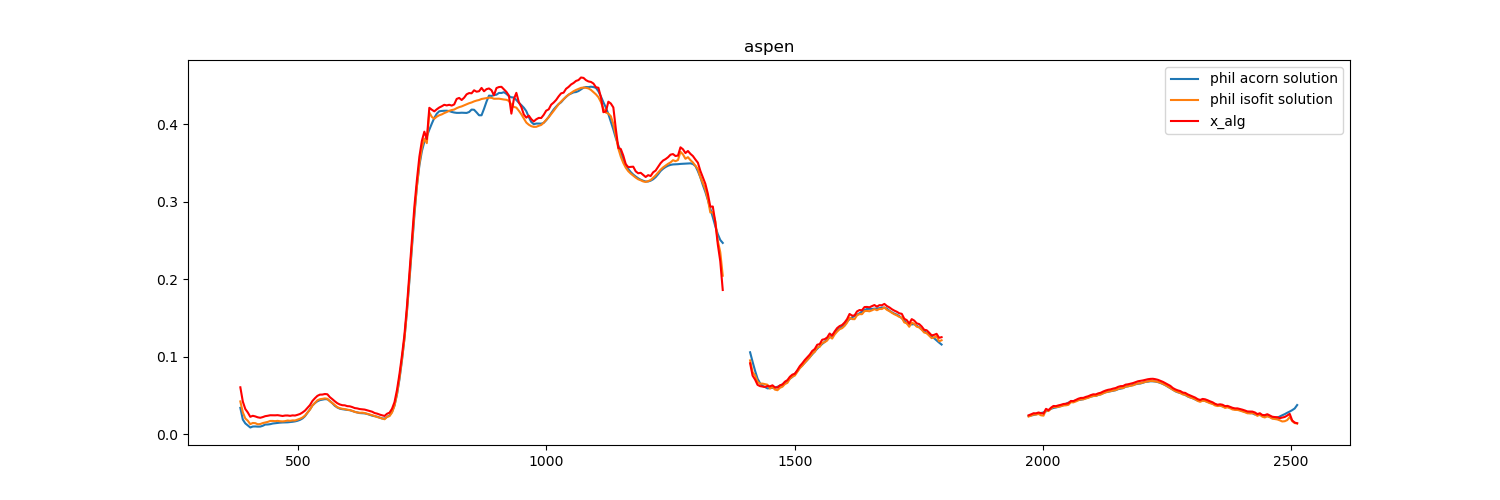

In [7]:
# aspen

k = 'aspen'
fol = aspen

# load, update config file
fp = glob(os.path.join(fol, '*', 'config', '*_isofit.json'))[0]
config = configs.create_new_config(fp)
config.forward_model.surface.surface_file = os.path.join(home, 'test_roi/surface_20240103_avirii_20250730.mat') # different from what was used in apply_oe!
config.input.measured_radiance_file = glob(os.path.join(fol, 'subset', '*_rdn'))[0]
config.input.obs_file = glob(os.path.join(fol, 'subset', '*_obs'))[0]
config.input.loc_file = glob(os.path.join(fol, 'subset', '*_igm'))[0]

# run retrieval
x_alg, Ls, coeffs, wl = single_px_retrieval(config, rdn[k], obs[k], loc[k])

# compare w Phil retrievals (original acorn, isofit)
rfl_acorn = envi.open(aspen + '/subset/min_phase_refl.hdr').open_memmap(interleave='bip').copy()/10000
rfl_isofit = envi.open(aspen + 'subset/min_phase_isofit_rfl.hdr').open_memmap(interleave='bip').copy()
rfl_acorn[valid==False,:] = np.nan
rfl_isofit[valid==False,:] = np.nan
rfl_acorn = np.nanmean(rfl_acorn, axis=(0, 1))
rfl_isofit = np.nanmean(rfl_isofit, axis=(0, 1))

fig = plt.figure(figsize=(15,5))
plt.plot(wl, rfl_acorn, label='phil acorn solution')
plt.plot(wl, rfl_isofit, label='phil isofit solution')
# plt.plot(wl, x_surface, label='x_surface')
plt.plot(wl, x_alg, label='x_alg', c='red')
plt.title(f'{k}')
plt.legend()
plt.show()

INFO:root:Loading config file: /store/carroll/col/2018/test_roi/aspen/NIS01_20180619_172934_sRTMnet/config/NIS01_20180619_172934_isofit.json
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/radiative_transfer_engine.py:Loading from wavelength_file: /store/carroll/col/2018/test_roi/aspen/NIS01_20180619_172934_sRTMnet/data/wavelengths.txt
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/radiative_transfer_engine.py:Prebuilt LUT provided



 300


INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/luts.py:Loading LUT into memory
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/radiative_transfer_engine.py:LUT grid loaded from file: OrderedDict({'AOT550': [0.0001, 0.050098333333333335, 0.10009666666666667, 0.15009499999999998, 0.20009333333333332, 0.25009166666666666, 0.30008999999999997, 0.35008833333333333, 0.40008666666666665, 0.45008499999999996, 0.5000833333333333, 0.5500816666666667, 0.60008, 0.6500783333333333, 0.7000766666666667, 0.7500749999999999, 0.8000733333333333, 0.8500716666666667, 0.9000699999999999, 0.9500683333333333, 1.0000666666666667, 1.050065, 1.1000633333333334, 1.1500616666666665, 1.20006, 1.2500583333333333, 1.3000566666666666, 1.350055, 1.4000533333333334, 1.4500516666666665, 1.5000499999999999, 1.5500483333333333, 1.6000466666666666, 1.650045, 1.7000433333333334, 1.7500416666666667, 1.8000399999999999


 325


INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/luts.py:Loading LUT into memory
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/radiative_transfer_engine.py:LUT grid loaded from file: OrderedDict({'AOT550': [0.0001, 0.050098333333333335, 0.10009666666666667, 0.15009499999999998, 0.20009333333333332, 0.25009166666666666, 0.30008999999999997, 0.35008833333333333, 0.40008666666666665, 0.45008499999999996, 0.5000833333333333, 0.5500816666666667, 0.60008, 0.6500783333333333, 0.7000766666666667, 0.7500749999999999, 0.8000733333333333, 0.8500716666666667, 0.9000699999999999, 0.9500683333333333, 1.0000666666666667, 1.050065, 1.1000633333333334, 1.1500616666666665, 1.20006, 1.2500583333333333, 1.3000566666666666, 1.350055, 1.4000533333333334, 1.4500516666666665, 1.5000499999999999, 1.5500483333333333, 1.6000466666666666, 1.650045, 1.7000433333333334, 1.7500416666666667, 1.8000399999999999

...

INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/luts.py:Loading LUT into memory
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/radiative_transfer_engine.py:LUT grid loaded from file: OrderedDict({'AOT550': [0.0001, 0.050098333333333335, 0.10009666666666667, 0.15009499999999998, 0.20009333333333332, 0.25009166666666666, 0.30008999999999997, 0.35008833333333333, 0.40008666666666665, 0.45008499999999996, 0.5000833333333333, 0.5500816666666667, 0.60008, 0.6500783333333333, 0.7000766666666667, 0.7500749999999999, 0.8000733333333333, 0.8500716666666667, 0.9000699999999999, 0.9500683333333333, 1.0000666666666667, 1.050065, 1.1000633333333334, 1.1500616666666665, 1.20006, 1.2500583333333333, 1.3000566666666666, 1.350055, 1.4000533333333334, 1.4500516666666665, 1.5000499999999999, 1.5500483333333333, 1.6000466666666666, 1.650045, 1.7000433333333334, 1.7500416666666667, 1.8000399999999999


 475


INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/luts.py:Loading LUT into memory
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/radiative_transfer_engine.py:LUT grid loaded from file: OrderedDict({'AOT550': [0.0001, 0.050098333333333335, 0.10009666666666667, 0.15009499999999998, 0.20009333333333332, 0.25009166666666666, 0.30008999999999997, 0.35008833333333333, 0.40008666666666665, 0.45008499999999996, 0.5000833333333333, 0.5500816666666667, 0.60008, 0.6500783333333333, 0.7000766666666667, 0.7500749999999999, 0.8000733333333333, 0.8500716666666667, 0.9000699999999999, 0.9500683333333333, 1.0000666666666667, 1.050065, 1.1000633333333334, 1.1500616666666665, 1.20006, 1.2500583333333333, 1.3000566666666666, 1.350055, 1.4000533333333334, 1.4500516666666665, 1.5000499999999999, 1.5500483333333333, 1.6000466666666666, 1.650045, 1.7000433333333334, 1.7500416666666667, 1.8000399999999999


 500


INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/luts.py:Loading LUT into memory
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/radiative_transfer_engine.py:LUT grid loaded from file: OrderedDict({'AOT550': [0.0001, 0.050098333333333335, 0.10009666666666667, 0.15009499999999998, 0.20009333333333332, 0.25009166666666666, 0.30008999999999997, 0.35008833333333333, 0.40008666666666665, 0.45008499999999996, 0.5000833333333333, 0.5500816666666667, 0.60008, 0.6500783333333333, 0.7000766666666667, 0.7500749999999999, 0.8000733333333333, 0.8500716666666667, 0.9000699999999999, 0.9500683333333333, 1.0000666666666667, 1.050065, 1.1000633333333334, 1.1500616666666665, 1.20006, 1.2500583333333333, 1.3000566666666666, 1.350055, 1.4000533333333334, 1.4500516666666665, 1.5000499999999999, 1.5500483333333333, 1.6000466666666666, 1.650045, 1.7000433333333334, 1.7500416666666667, 1.8000399999999999

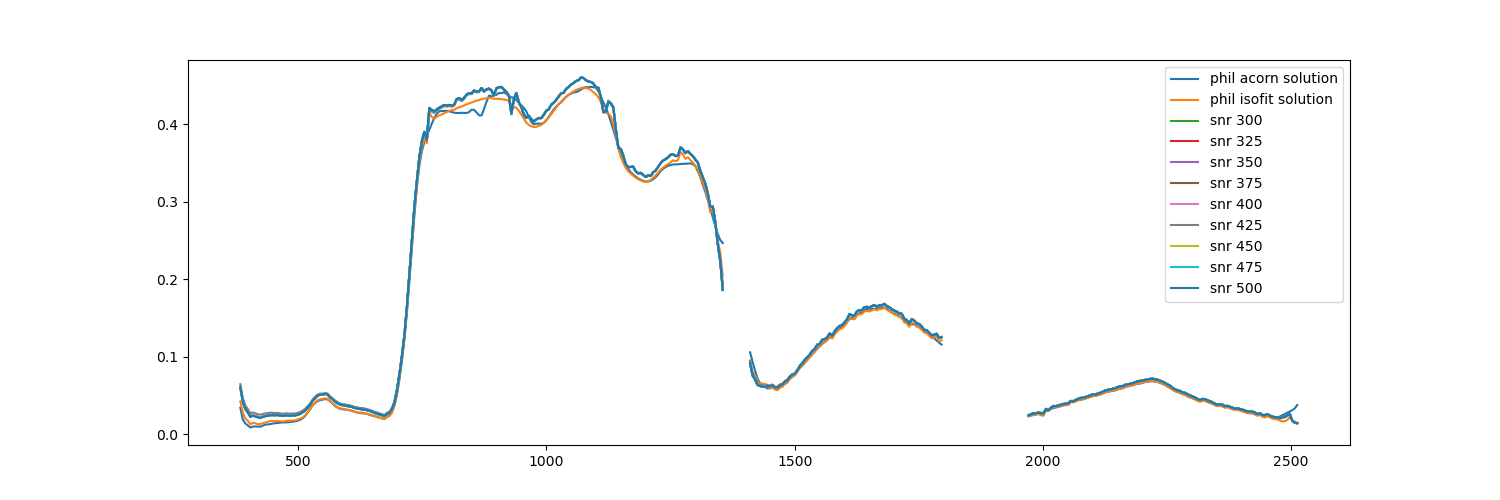

In [84]:
# test SNRs

k = 'aspen'
fol = aspen
fp = glob(os.path.join(fol, '*', 'config', '*_isofit.json'))[0]

# compare w Phil retrievals (original acorn, isofit)
rfl_acorn = envi.open(aspen + '/subset/min_phase_refl.hdr').open_memmap(interleave='bip').copy()/10000
rfl_isofit = envi.open(aspen + 'subset/min_phase_isofit_rfl.hdr').open_memmap(interleave='bip').copy()
rfl_acorn[valid==False,:] = np.nan
rfl_isofit[valid==False,:] = np.nan
rfl_acorn = np.nanmean(rfl_acorn, axis=(0, 1))
rfl_isofit = np.nanmean(rfl_isofit, axis=(0, 1))

fig = plt.figure(figsize=(15,5))
plt.plot(wl, rfl_acorn, label='phil acorn solution')
plt.plot(wl, rfl_isofit, label='phil isofit solution')

step = 25
for snr in range(300, 500+step, step):
    print('\n', snr)
    
    # load, update config file
    config = configs.create_new_config(fp)
    config.forward_model.surface.surface_file = os.path.join(home, 'test_roi/surface_20240103_avirii_20250730.mat') # different from what was used in apply_oe!
    config.input.measured_radiance_file = glob(os.path.join(fol, 'subset', '*_rdn'))[0]
    config.input.obs_file = glob(os.path.join(fol, 'subset', '*_obs'))[0]
    config.input.loc_file = glob(os.path.join(fol, 'subset', '*_igm'))[0]
    config.forward_model.instrument.SNR = snr # testing
    
    # run retrieval
    x_alg, Ls, coeffs, wl = single_px_retrieval(config, rdn[k], obs[k], loc[k], plot=False)
    
    # visualize solutions
    plt.plot(wl, x_alg, label=f'snr {snr}')
    
plt.legend()
plt.show()

INFO:root:Loading config file: /store/carroll/col/2018/test_roi/calTarp/NIS01_20180611_172310_sRTMnet/config/NIS01_20180611_172310_isofit.json
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/radiative_transfer_engine.py:Loading from wavelength_file: /store/carroll/col/2018/test_roi/calTarp/NIS01_20180611_172310_sRTMnet/data/wavelengths.txt
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/radiative_transfer_engine.py:Prebuilt LUT provided



 300


INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/luts.py:Loading LUT into memory
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/radiative_transfer_engine.py:LUT grid loaded from file: OrderedDict({'AOT550': [0.0001, 0.050098333333333335, 0.10009666666666667, 0.15009499999999998, 0.20009333333333332, 0.25009166666666666, 0.30008999999999997, 0.35008833333333333, 0.40008666666666665, 0.45008499999999996, 0.5000833333333333, 0.5500816666666667, 0.60008, 0.6500783333333333, 0.7000766666666667, 0.7500749999999999, 0.8000733333333333, 0.8500716666666667, 0.9000699999999999, 0.9500683333333333, 1.0000666666666667, 1.050065, 1.1000633333333334, 1.1500616666666665, 1.20006, 1.2500583333333333, 1.3000566666666666, 1.350055, 1.4000533333333334, 1.4500516666666665, 1.5000499999999999, 1.5500483333333333, 1.6000466666666666, 1.650045, 1.7000433333333334, 1.7500416666666667, 1.8000399999999999


 325


INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/luts.py:Loading LUT into memory
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/radiative_transfer_engine.py:LUT grid loaded from file: OrderedDict({'AOT550': [0.0001, 0.050098333333333335, 0.10009666666666667, 0.15009499999999998, 0.20009333333333332, 0.25009166666666666, 0.30008999999999997, 0.35008833333333333, 0.40008666666666665, 0.45008499999999996, 0.5000833333333333, 0.5500816666666667, 0.60008, 0.6500783333333333, 0.7000766666666667, 0.7500749999999999, 0.8000733333333333, 0.8500716666666667, 0.9000699999999999, 0.9500683333333333, 1.0000666666666667, 1.050065, 1.1000633333333334, 1.1500616666666665, 1.20006, 1.2500583333333333, 1.3000566666666666, 1.350055, 1.4000533333333334, 1.4500516666666665, 1.5000499999999999, 1.5500483333333333, 1.6000466666666666, 1.650045, 1.7000433333333334, 1.7500416666666667, 1.8000399999999999

...

INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/luts.py:Loading LUT into memory
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/radiative_transfer_engine.py:LUT grid loaded from file: OrderedDict({'AOT550': [0.0001, 0.050098333333333335, 0.10009666666666667, 0.15009499999999998, 0.20009333333333332, 0.25009166666666666, 0.30008999999999997, 0.35008833333333333, 0.40008666666666665, 0.45008499999999996, 0.5000833333333333, 0.5500816666666667, 0.60008, 0.6500783333333333, 0.7000766666666667, 0.7500749999999999, 0.8000733333333333, 0.8500716666666667, 0.9000699999999999, 0.9500683333333333, 1.0000666666666667, 1.050065, 1.1000633333333334, 1.1500616666666665, 1.20006, 1.2500583333333333, 1.3000566666666666, 1.350055, 1.4000533333333334, 1.4500516666666665, 1.5000499999999999, 1.5500483333333333, 1.6000466666666666, 1.650045, 1.7000433333333334, 1.7500416666666667, 1.8000399999999999


 475


INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/luts.py:Loading LUT into memory
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/radiative_transfer_engine.py:LUT grid loaded from file: OrderedDict({'AOT550': [0.0001, 0.050098333333333335, 0.10009666666666667, 0.15009499999999998, 0.20009333333333332, 0.25009166666666666, 0.30008999999999997, 0.35008833333333333, 0.40008666666666665, 0.45008499999999996, 0.5000833333333333, 0.5500816666666667, 0.60008, 0.6500783333333333, 0.7000766666666667, 0.7500749999999999, 0.8000733333333333, 0.8500716666666667, 0.9000699999999999, 0.9500683333333333, 1.0000666666666667, 1.050065, 1.1000633333333334, 1.1500616666666665, 1.20006, 1.2500583333333333, 1.3000566666666666, 1.350055, 1.4000533333333334, 1.4500516666666665, 1.5000499999999999, 1.5500483333333333, 1.6000466666666666, 1.650045, 1.7000433333333334, 1.7500416666666667, 1.8000399999999999


 500


INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/luts.py:Loading LUT into memory
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/radiative_transfer_engine.py:LUT grid loaded from file: OrderedDict({'AOT550': [0.0001, 0.050098333333333335, 0.10009666666666667, 0.15009499999999998, 0.20009333333333332, 0.25009166666666666, 0.30008999999999997, 0.35008833333333333, 0.40008666666666665, 0.45008499999999996, 0.5000833333333333, 0.5500816666666667, 0.60008, 0.6500783333333333, 0.7000766666666667, 0.7500749999999999, 0.8000733333333333, 0.8500716666666667, 0.9000699999999999, 0.9500683333333333, 1.0000666666666667, 1.050065, 1.1000633333333334, 1.1500616666666665, 1.20006, 1.2500583333333333, 1.3000566666666666, 1.350055, 1.4000533333333334, 1.4500516666666665, 1.5000499999999999, 1.5500483333333333, 1.6000466666666666, 1.650045, 1.7000433333333334, 1.7500416666666667, 1.8000399999999999

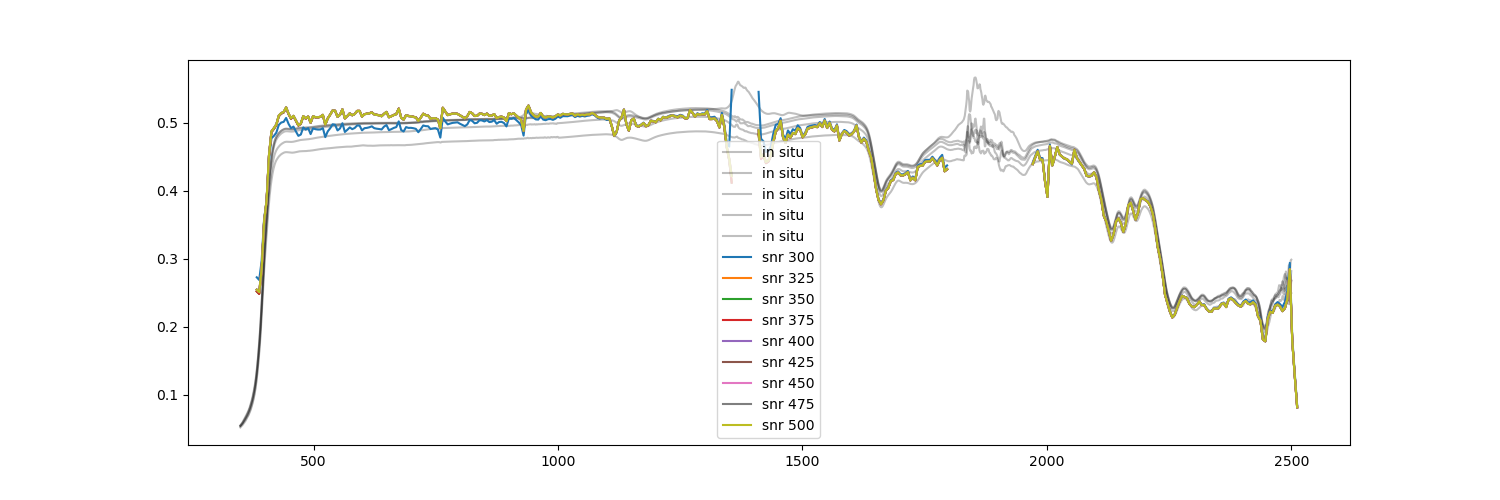

In [85]:
# test SNRs

k = 'WhiteTarp'
fol = cal
fp = glob(os.path.join(fol, '*', 'config', '*_isofit.json'))[0]

fig = plt.figure(figsize=(15,5))

# compare w insitu
fps = glob(os.path.join(dir_insitu, f'KBDU_*white', 'Data', f'KBDU_*white_Refl.dat'))
for fp_ in fps:
    in_situ = np.genfromtxt(fp_, skip_header=3)
    plt.plot(in_situ[:,0], in_situ[:,1], label=f'in situ',c='black', alpha=0.25)

step = 25
for snr in range(300, 500+step, step):
    print('\n', snr)
    
    # load, update config file
    config = configs.create_new_config(fp)
    config.forward_model.surface.surface_file = os.path.join(home, 'test_roi/surface_20240103_avirii_20250730.mat') # different from what was used in apply_oe!
    config.input.measured_radiance_file = glob(os.path.join(fol, 'subset', '*_rdn'))[0]
    config.input.obs_file = glob(os.path.join(fol, 'subset', '*_obs'))[0]
    config.input.loc_file = glob(os.path.join(fol, 'subset', '*_igm'))[0]
    config.forward_model.instrument.SNR = snr # testing
    
    # run retrieval
    x_alg, Ls, coeffs, wl = single_px_retrieval(config, rdn[k], obs[k], loc[k], plot=False)
    
    # visualize solutions
    plt.plot(wl, x_alg, label=f'snr {snr}')
    
plt.legend()
plt.show()

INFO:root:Loading config file: /store/carroll/col/2018/test_roi/calTarp/NIS01_20180611_172310_sRTMnet/config/NIS01_20180611_172310_isofit.json
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/radiative_transfer_engine.py:Loading from wavelength_file: /store/carroll/col/2018/test_roi/calTarp/NIS01_20180611_172310_sRTMnet/data/wavelengths.txt
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/radiative_transfer_engine.py:Prebuilt LUT provided



 300


INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/luts.py:Loading LUT into memory
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/radiative_transfer_engine.py:LUT grid loaded from file: OrderedDict({'AOT550': [0.0001, 0.050098333333333335, 0.10009666666666667, 0.15009499999999998, 0.20009333333333332, 0.25009166666666666, 0.30008999999999997, 0.35008833333333333, 0.40008666666666665, 0.45008499999999996, 0.5000833333333333, 0.5500816666666667, 0.60008, 0.6500783333333333, 0.7000766666666667, 0.7500749999999999, 0.8000733333333333, 0.8500716666666667, 0.9000699999999999, 0.9500683333333333, 1.0000666666666667, 1.050065, 1.1000633333333334, 1.1500616666666665, 1.20006, 1.2500583333333333, 1.3000566666666666, 1.350055, 1.4000533333333334, 1.4500516666666665, 1.5000499999999999, 1.5500483333333333, 1.6000466666666666, 1.650045, 1.7000433333333334, 1.7500416666666667, 1.8000399999999999


 325


INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/luts.py:Loading LUT into memory
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/radiative_transfer_engine.py:LUT grid loaded from file: OrderedDict({'AOT550': [0.0001, 0.050098333333333335, 0.10009666666666667, 0.15009499999999998, 0.20009333333333332, 0.25009166666666666, 0.30008999999999997, 0.35008833333333333, 0.40008666666666665, 0.45008499999999996, 0.5000833333333333, 0.5500816666666667, 0.60008, 0.6500783333333333, 0.7000766666666667, 0.7500749999999999, 0.8000733333333333, 0.8500716666666667, 0.9000699999999999, 0.9500683333333333, 1.0000666666666667, 1.050065, 1.1000633333333334, 1.1500616666666665, 1.20006, 1.2500583333333333, 1.3000566666666666, 1.350055, 1.4000533333333334, 1.4500516666666665, 1.5000499999999999, 1.5500483333333333, 1.6000466666666666, 1.650045, 1.7000433333333334, 1.7500416666666667, 1.8000399999999999

...

INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/luts.py:Loading LUT into memory
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/radiative_transfer_engine.py:LUT grid loaded from file: OrderedDict({'AOT550': [0.0001, 0.050098333333333335, 0.10009666666666667, 0.15009499999999998, 0.20009333333333332, 0.25009166666666666, 0.30008999999999997, 0.35008833333333333, 0.40008666666666665, 0.45008499999999996, 0.5000833333333333, 0.5500816666666667, 0.60008, 0.6500783333333333, 0.7000766666666667, 0.7500749999999999, 0.8000733333333333, 0.8500716666666667, 0.9000699999999999, 0.9500683333333333, 1.0000666666666667, 1.050065, 1.1000633333333334, 1.1500616666666665, 1.20006, 1.2500583333333333, 1.3000566666666666, 1.350055, 1.4000533333333334, 1.4500516666666665, 1.5000499999999999, 1.5500483333333333, 1.6000466666666666, 1.650045, 1.7000433333333334, 1.7500416666666667, 1.8000399999999999


 475


INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/luts.py:Loading LUT into memory
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/radiative_transfer_engine.py:LUT grid loaded from file: OrderedDict({'AOT550': [0.0001, 0.050098333333333335, 0.10009666666666667, 0.15009499999999998, 0.20009333333333332, 0.25009166666666666, 0.30008999999999997, 0.35008833333333333, 0.40008666666666665, 0.45008499999999996, 0.5000833333333333, 0.5500816666666667, 0.60008, 0.6500783333333333, 0.7000766666666667, 0.7500749999999999, 0.8000733333333333, 0.8500716666666667, 0.9000699999999999, 0.9500683333333333, 1.0000666666666667, 1.050065, 1.1000633333333334, 1.1500616666666665, 1.20006, 1.2500583333333333, 1.3000566666666666, 1.350055, 1.4000533333333334, 1.4500516666666665, 1.5000499999999999, 1.5500483333333333, 1.6000466666666666, 1.650045, 1.7000433333333334, 1.7500416666666667, 1.8000399999999999


 500


INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/luts.py:Loading LUT into memory
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/radiative_transfer_engine.py:LUT grid loaded from file: OrderedDict({'AOT550': [0.0001, 0.050098333333333335, 0.10009666666666667, 0.15009499999999998, 0.20009333333333332, 0.25009166666666666, 0.30008999999999997, 0.35008833333333333, 0.40008666666666665, 0.45008499999999996, 0.5000833333333333, 0.5500816666666667, 0.60008, 0.6500783333333333, 0.7000766666666667, 0.7500749999999999, 0.8000733333333333, 0.8500716666666667, 0.9000699999999999, 0.9500683333333333, 1.0000666666666667, 1.050065, 1.1000633333333334, 1.1500616666666665, 1.20006, 1.2500583333333333, 1.3000566666666666, 1.350055, 1.4000533333333334, 1.4500516666666665, 1.5000499999999999, 1.5500483333333333, 1.6000466666666666, 1.650045, 1.7000433333333334, 1.7500416666666667, 1.8000399999999999

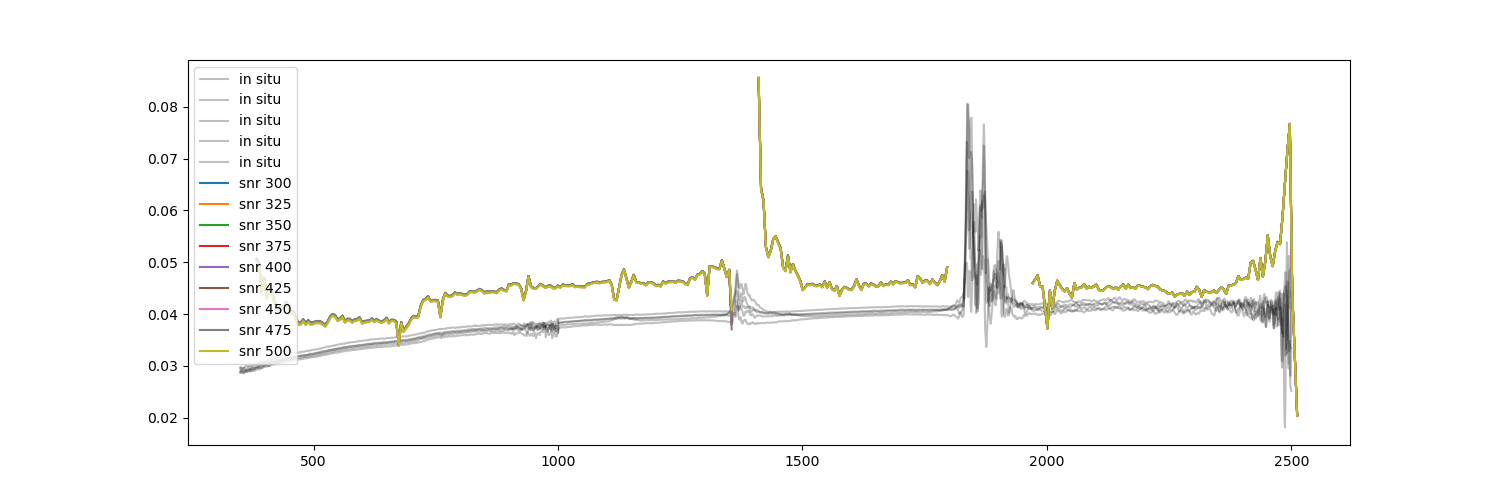

In [86]:
# test SNRs

k = 'BlackTarp'
fol = cal
fp = glob(os.path.join(fol, '*', 'config', '*_isofit.json'))[0]

fig = plt.figure(figsize=(15,5))

# compare w insitu
fps = glob(os.path.join(dir_insitu, f'KBDU_*black', 'Data', f'KBDU_*black_Refl.dat'))
for fp_ in fps:
    in_situ = np.genfromtxt(fp_, skip_header=3)
    plt.plot(in_situ[:,0], in_situ[:,1], label=f'in situ',c='black', alpha=0.25)

step = 25
for snr in range(300, 500+step, step):
    print('\n', snr)
    
    # load, update config file
    config = configs.create_new_config(fp)
    config.forward_model.surface.surface_file = os.path.join(home, 'test_roi/surface_20240103_avirii_20250730.mat') # different from what was used in apply_oe!
    config.input.measured_radiance_file = glob(os.path.join(fol, 'subset', '*_rdn'))[0]
    config.input.obs_file = glob(os.path.join(fol, 'subset', '*_obs'))[0]
    config.input.loc_file = glob(os.path.join(fol, 'subset', '*_igm'))[0]
    config.forward_model.instrument.SNR = snr # testing
    
    # run retrieval
    x_alg, Ls, coeffs, wl = single_px_retrieval(config, rdn[k], obs[k], loc[k], plot=False)
    
    # visualize solutions
    plt.plot(wl, x_alg, label=f'snr {snr}')
    
plt.legend()
plt.show()